# Test Data Plotting

In [1]:
import sys
import ijson
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

---
## Loading Data

In [2]:
CLIP_ID = 15

clip = np.load(f"data/npz/clip_{CLIP_ID}.npz", allow_pickle=True)
print(clip)

NUM_FRAMES = len(clip["timestamps"])
NUM_JOINTS = len(clip["actors"][0].item()["body"].keys())

print(f"NUM_FRAMES = {NUM_FRAMES}")
print(f"NUM_JOINTS = {NUM_JOINTS}")

NpzFile 'data/npz/clip_15.npz' with keys: timestamps, actors
NUM_FRAMES = 692
NUM_JOINTS = 63


In [3]:
frame = 0
actor = clip["actors"][frame].item()

for key, val in actor.items():
    if key == "body":
        print(f"{key}:")
        for joint, placement in val.items():
            print(f"\t{joint}:")
            print(f"\t\tposition: {np.array([pos for pos in placement["position"].values()]).astype(float)}")
            print(f"\t\trotation: {np.array([rot for rot in placement["rotation"].values()]).astype(float)}")
    else:
        print(f"{key}: {val}")

name: Peary
color: [217, 119, 150]
meta: {'hasGloves': True, 'hasLeftGlove': True, 'hasRightGlove': True, 'hasBody': True, 'hasFace': True}
dimensions: {'totalHeight': Decimal('1.59'), 'hipHeight': Decimal('0.8866271')}
body:
	hip:
		position: [1.516913   0.8838409  0.95777893]
		rotation: [ 0.01266852 -0.01959823 -0.00168619 -0.9997263 ]
	spine:
		position: [1.51466906 0.9841966  0.9079854 ]
		rotation: [-0.02616317 -0.01790943 -0.99948937  0.00397297]
	chest:
		position: [1.51143253 1.19895685 0.8977181 ]
		rotation: [ 0.03930681  0.02840291  0.99878687 -0.00855247]
	neck:
		position: [1.5084269  1.35427809 0.8889944 ]
		rotation: [ 0.02281163 -0.02670788  0.9992813  -0.01424731]
	head:
		position: [1.50578988 1.45085621 0.89422184]
		rotation: [ 0.00624024 -0.08172942  0.9964364  -0.01989454]
	leftShoulder:
		position: [1.4568578  1.29433262 0.9112655 ]
		rotation: [-0.03123322  0.08180315  0.70610553 -0.70267177]
	leftUpperArm:
		position: [1.31771231 1.29420877 0.88879603]
		rotat

---
## Accumulating Frames

In [4]:
joint = 'hip'
positions = np.empty(shape=(NUM_FRAMES, 3))
actor = clip["actors"]

for f in range(NUM_FRAMES):
    pos = actor[f].item()["body"][joint]["position"]
    positions[f, 0] = pos["x"]
    positions[f, 1] = pos["y"]
    positions[f, 2] = pos["z"]

    sys.stdout.write(f"\rsaving frame {f + 1}/{NUM_FRAMES}")
    sys.stdout.flush()

positions

saving frame 692/692

array([[1.516913  , 0.8838409 , 0.95777893],
       [1.516913  , 0.8838409 , 0.95777893],
       [1.51702392, 0.88384175, 0.9577148 ],
       ...,
       [1.529868  , 0.88476604, 0.97190166],
       [1.529868  , 0.88476604, 0.97190166],
       [1.53006268, 0.88476336, 0.97206974]], shape=(692, 3))

---
## Plots

### Separate Coordinate Signals

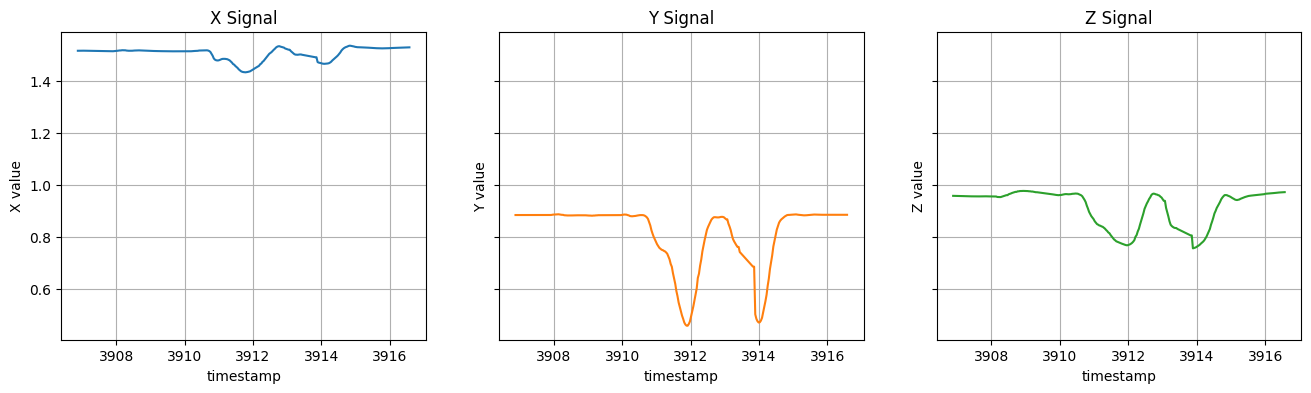

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True, sharex=True)
axes_label = ["X", "Y", "Z"]

for i, ax in enumerate(axs):
    ax.plot(clip["timestamps"], positions[:, i], c=f"C{i}")
    
    ax.set_title(f"{axes_label[i]} Signal")
    ax.set_xlabel("timestamp")
    ax.set_ylabel(f"{axes_label[i]} value")
    ax.grid()

plt.show()

### 3D Trajectory

In [6]:
time = np.array(clip["timestamps"])

In [7]:
fig = go.Figure(go.Scatter3d(
    x=positions[:,0], y=positions[:,1], z=positions[:,2],
    mode='lines+markers',
    line=dict(width=4, color=time, colorscale='Viridis'),
    marker=dict(size=2, color=time, colorscale='Viridis', colorbar=dict(title='timestamp')),
    text=[f'frame {i}, t={f}' for i, f in enumerate(time)]
))

fig.update_layout(
    scene=dict(aspectmode='data'),                          # no stretching
    scene_camera=dict(up=dict(x=0, y=1, z=0)),              # Y-up
    width=1080, height=720, margin=dict(l=0, r=0, t=0, b=0),
)

fig.show()

### Animated Trajectory

In [13]:
# frame skipping (for lightweight)
stride = 2
fidx = list(range(0, NUM_FRAMES, stride))

# fixed bbox
lo, hi = positions.min(0), positions.max(0)
pad = (hi - lo).max() * 0.05

# trail length (frames)
trail_len = 20

In [14]:
def trail_head(f):
    """Get trajectory walker head+trail"""
    seg = positions[: f + 1]
    return [
        # head point
        go.Scatter3d(
            x=[positions[f, 0]],
            y=[positions[f, 1]],
            z=[positions[f, 2]],
            mode="markers",
            marker=dict(size=5, color="crimson"),
        ),
        # trail points
        go.Scatter3d(
            x=seg[f-20:f, 0],
            y=seg[f-20:f, 1],
            z=seg[f-20:f, 2],
            mode="lines",
            line=dict(width=5, color="crimson"),
        ),
    ]

In [16]:
full_plot = go.Scatter3d(
    x=positions[:, 0],
    y=positions[:, 1],
    z=positions[:, 2],
    mode="lines",
    line=dict(width=2, color="lightgray"),
    name="full path",
)

fig = go.Figure(data=[full_plot, *trail_head(0)])
fig.frames = [go.Frame(data=trail_head(f), traces=[1, 2], name=str(f)) for f in fidx]

fig.update_layout(
    scene=dict(
        aspectmode="data",
        xaxis=dict(range=[lo[0] - pad, hi[0] + pad]),
        yaxis=dict(range=[lo[1] - pad, hi[1] + pad]),
        zaxis=dict(range=[lo[2] - pad, hi[2] + pad]),
    ),
    scene_camera=dict(up=dict(x=0, y=1, z=0)),
    width=1200, height=520, margin=dict(l=0, r=0, t=0, b=0),
    showlegend=False,
    updatemenus=[
        dict(
            type="buttons",
            x=0.05,
            y=0.05,
            buttons=[
                dict(
                    label="Play",
                    method="animate",
                    args=[
                        None,
                        dict(frame=dict(duration=33, redraw=True), fromcurrent=True),
                    ],
                ),
                dict(
                    label="Pause",
                    method="animate",
                    args=[
                        [None],
                        dict(frame=dict(duration=0, redraw=False), mode="immediate"),
                    ],
                ),
            ],
        )
    ],
    sliders=[
        dict(
            steps=[
                dict(
                    method="animate",
                    label=str(f),
                    args=[
                        [str(f)],
                        dict(frame=dict(duration=0, redraw=True), mode="immediate"),
                    ],
                )
                for f in fidx
            ]
        )
    ],
)

fig.show()